# **Project - Part 1: Analyzing wildfire activities in Australia - Visualization** 

# __Table of Contents__

<ol>
    <li><a href="#Overview">Project Overview</a></li>
    <li><a href="#Objectives">Objectives</a></li>
    <li>
        <a href="#Setup">Setup</a>
        <ol>
            <li><a href="#Installing-Required-Libraries">Installing Required Libraries</a></li>
            <li><a href="#Importing-Required-Libraries">Importing Required Libraries</a></li>
    </li>
    <li>
        <a href="#Dataset">Dataset</a>
    </li>
    <li><a href="#Importing Dataset">Importing Dataset</a></li>
    <li><a href="#Visualization">Visualizations</a></li>
   


---


# Project Overview
This project is split into two parts. Part 1 will focus on plotting and visualization and Part 2 is about creating and customizing dashboards.

Part 1 : Analyzing the wildfire activities in Australia and creating visualizations

Part 2 : Dashboard to display charts based on selected Region and Year


## Part 1 : Analyzing the wildfire activities in Australia
### Objectives
The objective of this part of the project is to analyze and visualize the wildfire activities in Australia using the provided dataset. We will explore patterns and trends, and create visualizations to gain insights into the behavior of wildfires in different regions of Australia.

In this part we will create visualizations using libraries such as Matplotlib, Seaborn, Pandas and Folium.

### Tasks to be performed
- TASK 1.1: To understand the change in average estimated fire area over time using pandas to plot the line chart.
- TASK 1.2: To plot the estimated fire area over month
- TASK 1.3: Use the functionality of seaborn to develop a barplot, to find the insights on the distribution of mean estimated fire brightness across the regions
- TASK 1.4: Develop a pie chart and find the portion of count of pixels for presumed vegetation fires vary across regions
- TASK 1.5: Customize the previous pie plot for a better visual representation
- TASK 1.6: Use Matplotlib to develop a histogram of the mean estimated fire brightness
- TASK 1.7: Use the functionality of seaborn and pass region as hue, to understand the distribution of estimated fire brightness across regions
- TASK 1.8: Develop a scatter plot to find the correlation between mean estimated fire radiative power and mean confidence level
- TASK 1.9: Mark all seven regions affected by wildfires, on the Map of Australia using Folium

---


# Setup


For this project, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### Installing Required Libraries

If running this notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda), please install these libraries by removing the `#` sign before `%pip` in the code cell below.


In [ ]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
#%pip install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 folium
# Note: If your environment doesn't support "%pip install", use "!mamba install"

In [1]:
%pip install seaborn
%pip install folium

### Importing Required Libraries

_Import all required libraries in one place (here):_


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
%matplotlib inline

<ipython-input-2-b6dc58e0108d>:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


---


# Dataset

**Historical Wildfires**

This wildfire dataset contains data on fire activities in Australia starting from 2005. Additional information can be found [here](https://earthdata.nasa.gov/earth-observation-data/near-real-time/firms/c6-mcd14dl).

Variables

- Region: the 7 regions
- Date: in UTC and provide the data for 24 hours ahead
- Estimated_fire_area: daily sum of estimated fire area for presumed vegetation fires with a confidence > 75% for a each region in km2
- Mean_estimated_fire_brightness: daily mean (by flagged fire pixels(=count)) of estimated fire brightness for presumed vegetation fires with a confidence level > 75% in Kelvin
- Mean_estimated_fire_radiative_power: daily mean of estimated radiative power for presumed vegetation fires with a confidence level > 75% for a given region in megawatts
- Mean_confidence: daily mean of confidence for presumed vegetation fires with a confidence level > 75%
- Std_confidence: standard deviation of estimated fire radiative power in megawatts
- Var_confidence: Variance of estimated fire radiative power in megawatts
- Count: daily numbers of pixels for presumed vegetation fires with a confidence level of larger than 75% for a given region
- Replaced: Indicates with an Y whether the data has been replaced with standard quality data when they are available (usually with a 2-3 month lag). Replaced data has a slightly higher quality in terms of locations

---


### Importing Data


In [3]:
from js import fetch
import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv"
resp = await fetch(URL)
text = io.BytesIO((await resp.arrayBuffer()).to_py())
df = pd.read_csv(text)
print('Data read into a pandas dataframe!')


Data read into a pandas dataframe!


Let's look at some samples rows from the dataset we loaded:


In [4]:
df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R


---


Let's verify the column names and the data type of each variable


In [5]:
#Column names
df.columns

Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced'],
      dtype='object')

In [6]:
#data type
df.dtypes

Region                                  object
Date                                    object
Estimated_fire_area                    float64
Mean_estimated_fire_brightness         float64
Mean_estimated_fire_radiative_power    float64
Mean_confidence                        float64
Std_confidence                         float64
Var_confidence                         float64
Count                                    int64
Replaced                                object
dtype: object

Notice the type of 'Date' is object, let's convert it to 'datatime' type and also let's extract 'Year' and 'Month' from date and include in the dataframe as separate columns


In [7]:
import datetime as dt

df['Year'] = pd.to_datetime(df['Date']).dt.year
df['Month'] = pd.to_datetime(df['Date']).dt.month


**Verify the columns again**


In [8]:
df.dtypes

Region                                  object
Date                                    object
Estimated_fire_area                    float64
Mean_estimated_fire_brightness         float64
Mean_estimated_fire_radiative_power    float64
Mean_confidence                        float64
Std_confidence                         float64
Var_confidence                         float64
Count                                    int64
Replaced                                object
Year                                     int32
Month                                    int32
dtype: object

---


## Tasks


### TASK 1.1: Let's try to understand the change in average estimated fire area over time <br>(use pandas to plot)


We group the year for 'Estimated_fire_area' (taking its mean)<br>Then use df.plot() on it to create a line graph

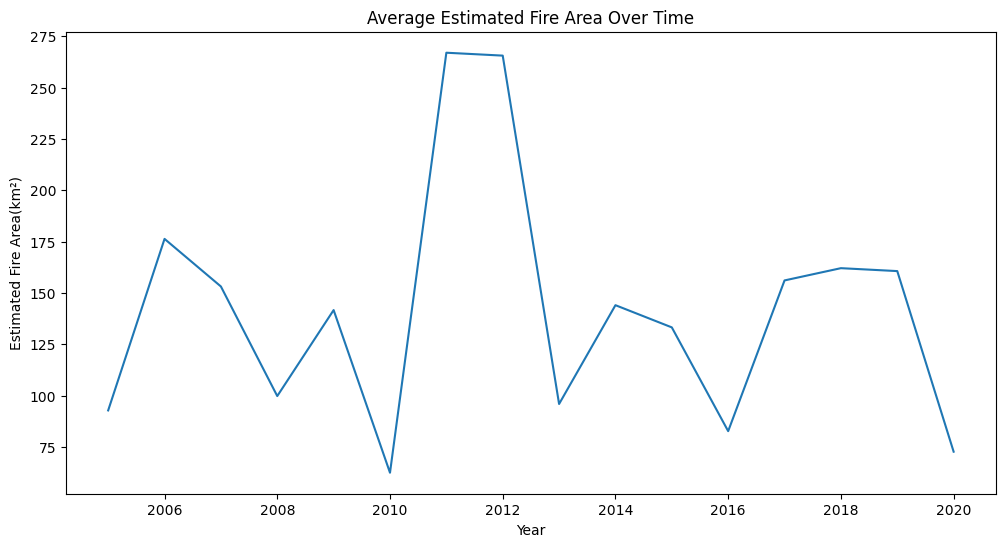

In [14]:
# Grouping the data by 'Year' and calculating the mean of 'Estimated_fire_area'
df_grouped_year = df.groupby('Year')['Estimated_fire_area'].mean()

# Plotting the data
plt.figure(figsize=(12, 6))
df_grouped_year.plot(kind='line',x=df_grouped_year.index, y=df_grouped_year.values)
plt.xlabel('Year')
plt.ylabel('Estimated Fire Area(km²)')
plt.title('Average Estimated Fire Area Over Time')
plt.show()

---


### TASK 1.2: We can notice the peak in the plot between 2010 to 2013. Let's narrow down our finding, by plotting the estimated fire area for year grouped together with month.


We group the year and month for 'Estimated_fire_area' (taking its mean)<br>Then use df.plot() on it to create a line graph

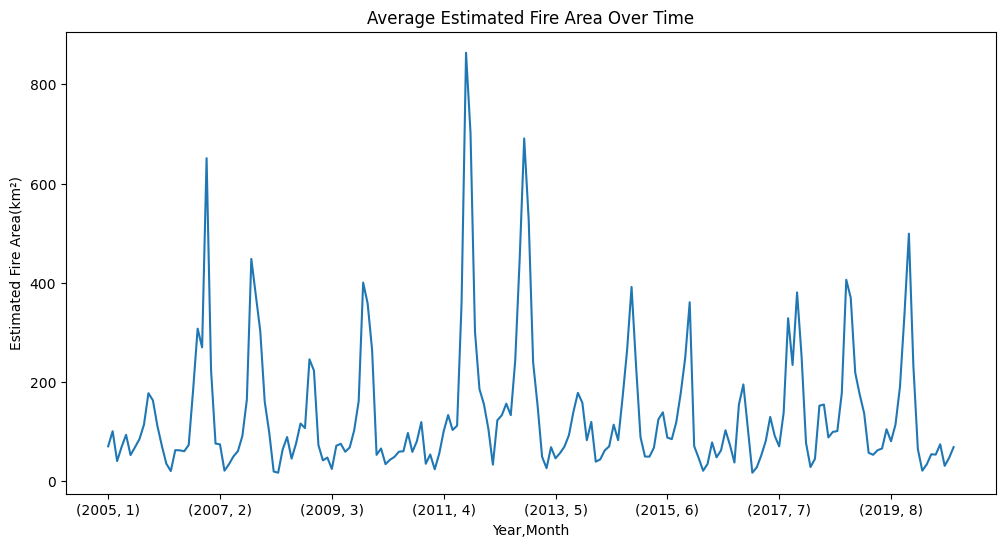

In [16]:
# Grouping the data by 'Year' and 'Month' and calculating the mean of 'Estimated_fire_area'
df_grouped_ym = df.groupby(['Year','Month'])['Estimated_fire_area'].mean()

# Plotting the data
plt.figure(figsize=(12, 6))
df_grouped_ym.plot(kind='line',x=df_grouped_ym.index, y=df_grouped_ym.values)
plt.xlabel('Year,Month')
plt.ylabel('Estimated Fire Area(km²)')
plt.title('Average Estimated Fire Area Over Time')
plt.show()

This plot represents that the estimated fire area was on its peak after 2011, April and before 2012. You can verify on google/news, this was the time of maximum wildfire hit in Austrailia


---


### TASK 1.3: Let's have an insight on the distribution of mean estimated fire brightness across the regions<br> use the functionality of seaborn to develop a barplot


before starting with the plot, why not know the regions mentioned in the dataset?. <br>We use unique() to identify the regions in the dataset (apply it on series only)


In [17]:
df['Region'].unique()

array(['NSW', 'NT', 'QL', 'SA', 'TA', 'VI', 'WA'], dtype=object)

Then we plot reions on x-axis and the 'Mean_estimated_fire_brightness' on y-axis.

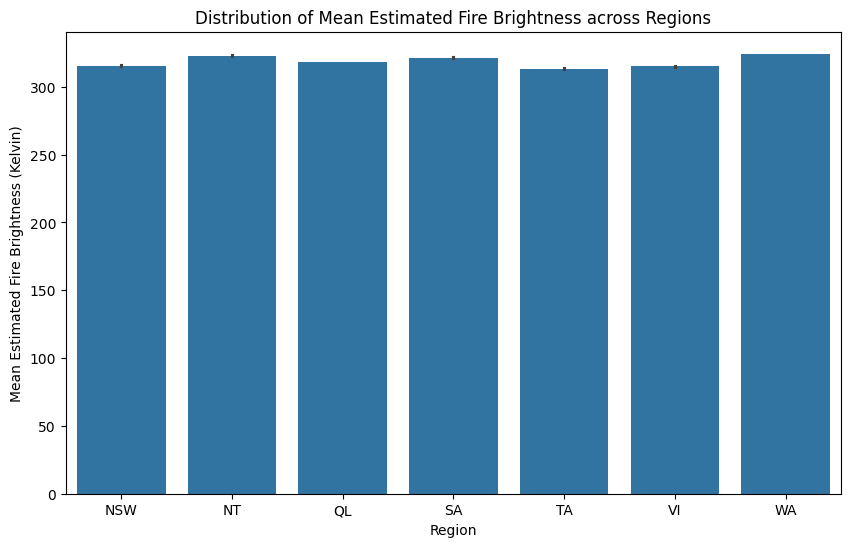

In [30]:
# Creating a bar plot using seaborn to visualize the distribution of mean estimated fire brightness across regions
plt.figure(figsize=(10, 6))

# Using seaborn's barplot function to create the plot
sns.barplot(data=df, x='Region', y='Mean_estimated_fire_brightness')
plt.xlabel('Region')
plt.ylabel('Mean Estimated Fire Brightness (Kelvin)')
plt.title('Distribution of Mean Estimated Fire Brightness across Regions')
plt.show()

---


### TASK 1.4: Let's find the portion of count of pixels for presumed vegetation fires vary across regions<br> we will develop a pie chart for this


First we need to group the data on region and find the sum of count

In [45]:
# Grouping the data by region and summing the counts
df_grouped_region  = df.groupby('Region')['Count'].sum()
df_grouped_region.head()

Region
NSW    117412
NT     649430
QL     420882
SA      35160
TA      11473
Name: Count, dtype: int64

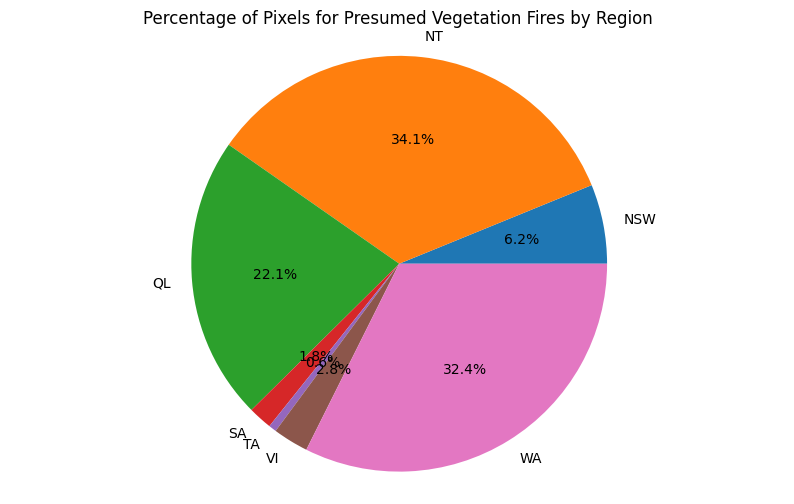

In [47]:
# Creating a pie chart to visualize the portion of count of pixels for presumed vegetation fires across regions
plt.figure(figsize=(10, 6))
# Creating the pie chart using plt.pie function
# Labels are set to the region names, and autopct is used to display percentage
plt.pie(df_grouped_region,labels=df_grouped_region.index,autopct='%1.1f%%')
plt.title('Percentage of Pixels for Presumed Vegetation Fires by Region')
plt.axis('equal')
plt.show()

### TASK 1.5: See the percentage on the pie is not looking so good as it is overlaped for Region SA, TA, VI 

Let's remove the autopct from pie function and pass the following to plt.legend() after plt.title() <br>
`[(i,round(k/region_counts.sum()*100,2)) for i,k in zip(region_counts.index, region_counts)]`


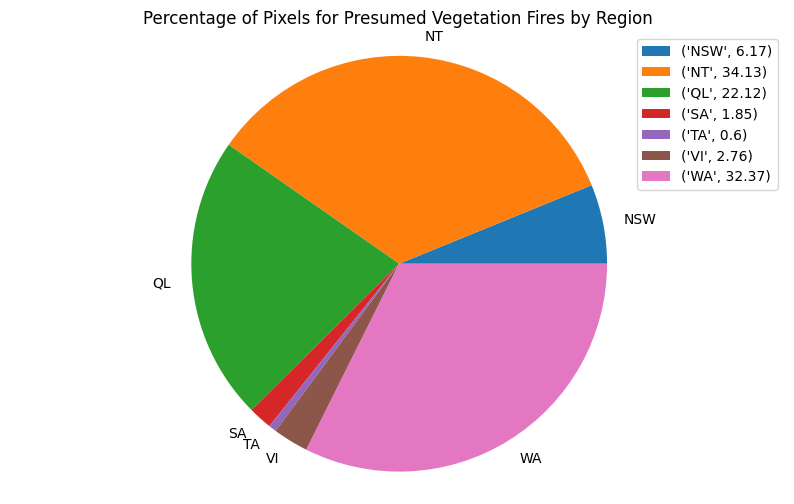

In [49]:
# Creating a pie chart to visualize the portion of count of pixels for presumed vegetation fires across regions
plt.figure(figsize=(10, 6))
# Creating the pie chart using plt.pie function
# Labels are set to the region names, and autopct is used to display percentage
plt.pie(df_grouped_region,labels=df_grouped_region.index)
plt.title('Percentage of Pixels for Presumed Vegetation Fires by Region')
plt.legend([(i,round(k/df_grouped_region.sum()*100,2)) for i,k in zip(df_grouped_region.index, df_grouped_region)])
plt.axis('equal')
plt.show()

---


### TASK 1.6: Let's try to develop a histogram of the mean estimated fire brightness<br> Using Matplotlib to create the histogram


We call plt.hist() and pass df['Mean_estimated_fire_brightness'] as x

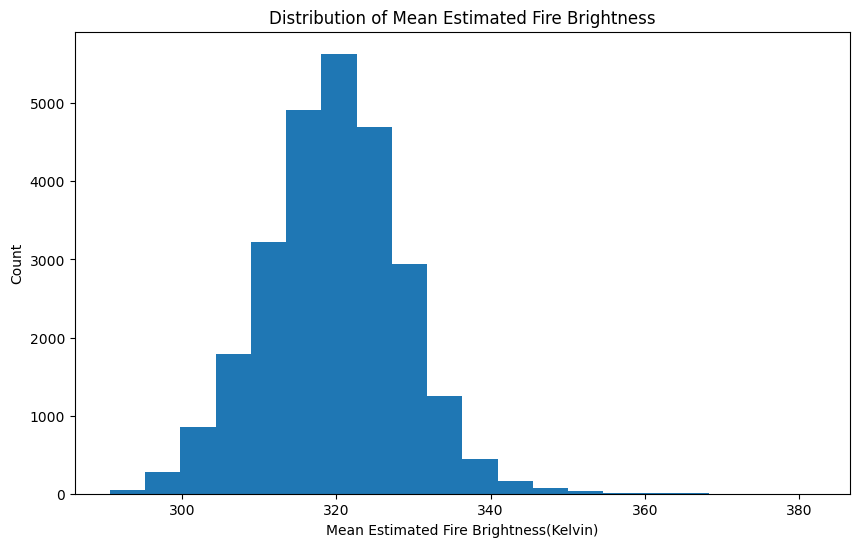

In [52]:
# Creating a histogram to visualize the distribution of mean estimated fire brightness
plt.figure(figsize=(10,6))

# Using plt.hist to create the histogram
# Setting the number of bins to 20 for better visualization
plt.hist(df['Mean_estimated_fire_brightness'],bins=20)
plt.title('Distribution of Mean Estimated Fire Brightness')
plt.xlabel('Mean Estimated Fire Brightness(Kelvin)')
plt.ylabel('Count')
plt.show()

### TASK 1.7: What if we need to understand the distribution of estimated fire brightness across regions? Let's use the functionality of seaborn and  pass region as hue


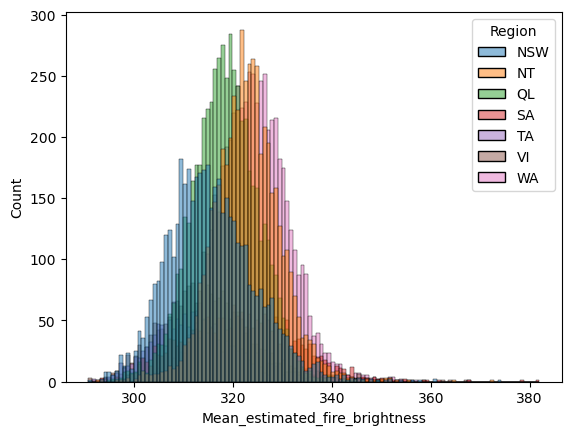

In [53]:
# Creating a histogram to visualize the distribution of mean estimated fire brightness across regions using Seaborn
# Using sns.histplot to create the histogram
# Adding hue='Region' to differentiate the distribution across regions
sns.histplot(data=df,x='Mean_estimated_fire_brightness',hue='Region')
plt.show()

### looks better!, now let's include the parameter `multiple='stack'` in the histplot() and see the difference. Include labels and titles as well

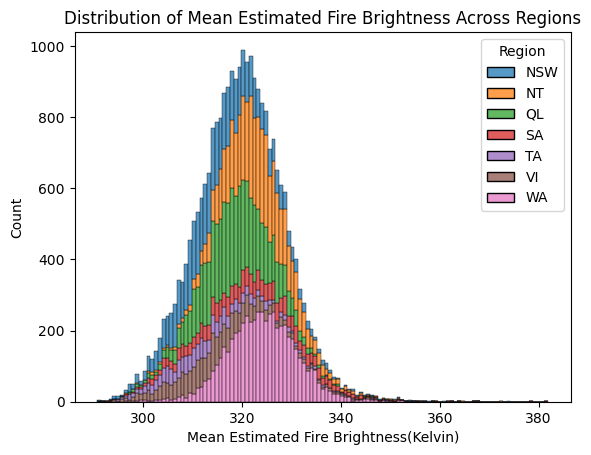

In [55]:
# Creating a stacked histogram to visualize the distribution of mean estimated fire brightness across regions using Seaborn
# Using sns.histplot to create the stacked histogram
# Adding hue='Region' to differentiate the distribution across regions
# Setting multiple='stack' to stack the histograms for different regions
sns.histplot(data=df,x='Mean_estimated_fire_brightness',hue='Region',multiple='stack')
plt.title('Distribution of Mean Estimated Fire Brightness Across Regions')
plt.xlabel('Mean Estimated Fire Brightness(Kelvin)')
plt.ylabel('Count')
plt.show()

---


### TASK 1.8: Let's try to find if there is any correlation between mean estimated fire radiative power and mean confidence level?


We call plt.scatter() to make a scatter plot.

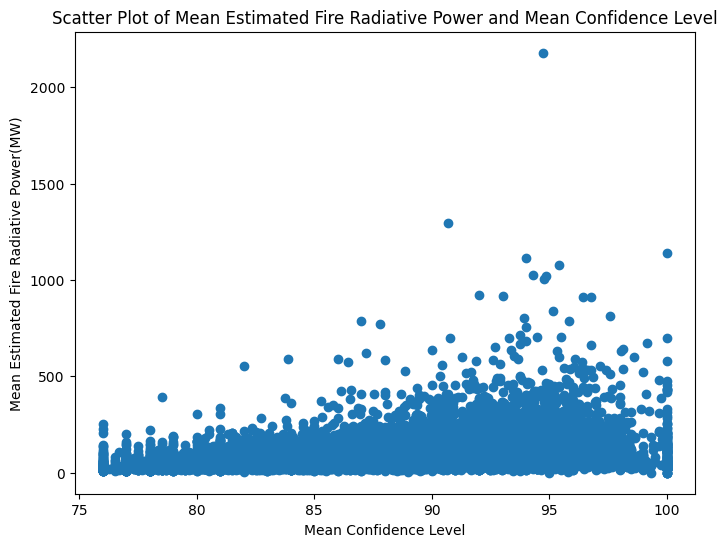

In [58]:
# Creating a scatter plot to visualize the relationship between mean estimated fire radiative power and mean  confidence using Seaborn
plt.figure(figsize=(8, 6))
plt.scatter(y=df['Mean_estimated_fire_radiative_power'],x=df['Mean_confidence'])
plt.title('Scatter Plot of Mean Estimated Fire Radiative Power and Mean Confidence Level')
plt.ylabel('Mean Estimated Fire Radiative Power(MW)')
plt.xlabel('Mean Confidence Level')
plt.show()

It seems that there is little or no correlation between mean estimated fire radiative power and mean confidence leve

---


### TASK 1.9: Let's mark these seven regions on the Map of Australia using Folium
For australia we use [-25, 135] as location to create the map


In [59]:
region_data = {'region':['NSW','QL','SA','TA','VI','WA','NT'], 'Lat':[-31.8759835,-22.1646782,-30.5343665,-42.035067,-36.5986096,-25.2303005,-19.491411], 
               'Lon':[147.2869493,144.5844903,135.6301212,146.6366887,144.6780052,121.0187246,132.550964]}
reg=pd.DataFrame(region_data)
reg

,region,Lat,Lon
0,NSW,-31.875984,147.286949
1,QL,-22.164678,144.584490
2,SA,-30.534367,135.630121
3,TA,-42.035067,146.636689
4,VI,-36.598610,144.678005
5,WA,-25.230300,121.018725
6,NT,-19.491411,132.550964


In [61]:
# Create a Folium map centered on Australia
map_Australia = folium.Map(location=[-25,135],zoom_start=4)

# instantiate a feature group
group = folium.map.FeatureGroup()

# loop through the region and add to feature group
for lat,lon,region in zip(reg.Lat,reg.Lon,reg.region):
    group.add_child(
        folium.features.CircleMarker(
            location=[lat,lon],
            popup=region,
            radius=5,                  # define how big we want the circle markers to be
            color='red',
            fill_opacity=0.6,
            fill=True,
            fill_color='blue')
            )

# add incidents to map
map_Australia.add_child(group)

map_Australia

---


```{toggle}|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
```

```{toggle}|-|-|-|-|
```
```{toggle}|2023-06-281|0.2|Dr. Pooja|Initial Lab Creation|
```
```{toggle}|2023-05-01|0.1|Shengkai|Create Lab Template|
```
